### Sofia Casquinha - 20250838

# 1. Business Understanding

This section documents the business context, objectives, and project plan following the CRISP-DM methodology.

## 1.1 Determine Business Objectives

### Background

Hotel H is an independent hotel located in Lisbon, Portugal, member of hotel chain C. Until 2018, chain C operated 4 hotels. Following the acquisition of new properties, the group invested in a dedicated marketing department and appointed A as the new marketing manager.

A identified that the existing customer segmentation was inadequate for modern marketing operations. It reflected only one customer characteristic and provided no insight into geography, demographics, or behaviour. Without a meaningful segmentation, defining acquisition and retention strategies across the hotel's multiple distribution channels was not possible.

### Business Objective

The primary business objective is to replace the current origin-based customer segmentation with a data-driven behavioural segmentation of Hotel H's customer database. The segmentation must identify customer groups that differ in measurable, actionable ways, enabling the marketing department to define differentiated strategies for acquisition, retention, pricing, and channel management.

Secondary business questions:

- Which customers are most valuable and most at risk of not returning?
- Which distribution channels are associated with each customer type?
- Which nationalities are over- or under-represented in each segment?
- Are there identifiable loyal, repeat-visit customers that justify a loyalty programme?

### Business Success Criteria

The segmentation will be considered successful if:

1. At least three distinct customer segments are identified, each with a clear and differentiated behavioural profile that A can act on independently.
2. The segments produce actionable recommendations covering at minimum: retention strategy, re-engagement strategy, and channel prioritisation.

## 1.2 Assess Situation

### Inventory of Resources

**Data**: a single structured dataset extracted from Hotel H's Property Management System (PMS), provided as `HotelCustomersDataset.tsv`. The dataset contains 83,590 customer records and 31 variables covering demographics, booking behaviour, revenue, recency, and room preferences. The extraction reference date is 31 December 2018.

**Tools**: Python with pandas, scikit-learn, matplotlib, seaborn, and scipy.

### Requirements, Assumptions, and Constraints

**Requirements:**

- The segmentation must be interpretable without statistical expertise, A must be able to understand and use the output.
- Segments must be described in business language with marketing implications.
- The project must be reproducible from the raw dataset.

**Assumptions:**

- The dataset is a complete extract of Hotel H's customer base as of 31 December 2018 and is representative of the hotel's current customer population.
- Customers with no completed stay (ghost customers, 23.8% of records) are not active customers and should not be included in the segmentation.
- The booking holder is the decision-maker, child companions (age < 18) are not.
- The PMS occasionally creates duplicate profiles for the same customer through user error. Where confirmed, these should be consolidated before segmentation.
- Revenue, recency, and loyalty span are the most relevant dimensions for differentiating customer value in a hotel context.

**Constraints:**

- The dataset covers a fixed historical period ending December 2018. No live data feed is available.
- Customer identity is anonymised through hashed identifiers. No personally identifiable information is available.
- The segmentation must be produced using unsupervised methods, as there are no predefined labels or outcome variables.

## 1.3 Determine Data Mining Goals

### Data Mining Goal

Apply unsupervised clustering to Hotel H's customer database to identify groups of customers with distinct behavioural profiles across recency, monetary value, and loyalty span.

The problem type is **descriptive clustering**.

The clustering model uses three variables derived from the customer database:

- `DaysSinceLastStay`: measures how recently a customer last stayed (recency).
- `TotalRevenue`: measures total spending across all stays (monetary value).
- `Tenure`: measures the time span between first and last stay (loyalty span).

These three dimensions follow the RFM (Recency, Frequency, Monetary) logic, adapted here to the hotel context where most customers have only one recorded stay.

### Data Mining Success Criteria

The data mining result will be considered successful if:

1. **Silhouette score ≥ 0.30** indicating that clusters are meaningfully separated given the complexity of the dataset.
2. **All clusters contain at least 5% of the active customer base** ensuring no segment is driven purely by outliers.
3. **Cluster profiles differ significantly on at least two of the three modelling variables** confirming that the segmentation captures real behavioural variation.
4. **The final segments can be named and described in business terms** confirming that the output is interpretable and actionable.

## 1.4 Project Plan

The project follows the CRISP-DM process model with the following phases:

| Phase | Key Activities | Output |
|-------|---------------|--------|
| Business Understanding | Define objectives, success criteria, data mining goals | This document |
| Data Understanding | Load and explore the dataset, verify quality | Data quality report, key findings |
| Data Preparation | Clean, engineer features, select modelling variables, scale | `X_model`, `df_profile` |
| Modeling | Hierarchical clustering (K guidance), K-Means (full dataset) | Final segmentation with K=4 |
| Evaluation | Assess segments against business objectives, review process | Segment descriptions, recommendations |
| Deployment | Document how segments should be used, maintenance plan | Deployment guide |

# 2. Data Understanding

## 2.1 Collect Initial Data

In [1]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../data/HotelCustomersDataset.tsv", sep='\t')
df.head()

,ID,Nationality,Age,DaysSinceCreation,NameHash,DocIDHash,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,0x8E0A7AF39B633D5EA25C3B7EF4DFC5464B36DB7AF375...,0x71568459B729F7A7ABBED6C781A84CA4274D571003AC...,45,371.0,105.3,1,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,0x21EDE41906B45079E75385B5AA33287CA09DE1AB86DE...,0x5FA1E0098A31497057C5A6B9FE9D49FD6DD47CCE7C26...,61,280.0,53.0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0x31C5E4B74E23231295FDB724AD578C02C4A723F4BA2B...,0xC7CF344F5B03295037595B1337AC905CA188F1B5B3A5...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,0xFF534C83C0EF23D1CE516BC80A65D0197003D27937D4...,0xBD3823A9B4EC35D6CAF4B27AE423A677C0200DB61E82...,93,240.0,60.0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0x9C1DEF02C9BE242842C1C1ABF2C5AA249A1EEB4763B4...,0xE175754CF77247B202DD0820F49407C762C14A603B3A...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0


## 2.2 Describe Data

### Variable Description

- **`ID`**: Customer ID.

- **`Nationality`**: Country of origin. Categories are represented in ISO 3155–3:2013 format.

- **`Age`**: Customer's age, in years, at the last day of the extraction period.

- **`DaysSinceCreation`**: Number of days since the customer record was created, measured between the creation date and the last day of the extraction period.

- **`NameHash`**: SHA2–256 hash string of the customer's name, used for anonymization.

- **`DocIDHash`**: SHA2–256 hash string of the identification document provided at check-in, such as passport number, national ID card, or another document.

- **`AverageLeadTime`**: Average number of days between the customer's booking date and arrival date. It is calculated by dividing the total lead time across bookings by the total number of bookings.

- **`LodgingRevenue`**: Total amount spent by the customer on lodging expenses, in euros. This includes room, crib, and other lodging-related expenses.

- **`OtherRevenue`**: Total amount spent by the customer on other expenses, in euros. This includes food, beverages, spa, and other non-lodging expenses.

- **`BookingsCanceled`**: Number of bookings made by the customer that were later canceled.

- **`BookingsNoShowed`**: Number of bookings where the customer did not cancel but also did not check in.

- **`BookingsCheckedIn`**: Number of bookings made by the customer that resulted in an actual stay.

- **`PersonsNights`**: Total number of person-nights stayed by the customer. It is calculated by multiplying the number of nights by the number of adults and children for each checked-in booking.

- **`RoomNights`**: Total number of room-nights stayed by the customer. It is calculated by multiplying the number of rooms by the number of nights for each checked-in booking.

- **`DaysSinceLastStay`**: Number of days between the last day of the extraction period and the customer's last arrival date for a checked-in booking. A value of `-1` means the customer never stayed at the hotel.

- **`DaysSinceFirstStay`**: Number of days between the last day of the extraction period and the customer's first arrival date for a checked-in booking. A value of `-1` means the customer never stayed at the hotel.

- **`DistributionChannel`**: Distribution channel usually used by the customer to make hotel bookings.

- **`MarketSegment`**: Current market segment of the customer.

- **`SRHighFloor`**: Indicates whether the customer usually asks for a room on a high floor. `0 = No`, `1 = Yes`.

- **`SRLowFloor`**: Indicates whether the customer usually asks for a room on a low floor. `0 = No`, `1 = Yes`.

- **`SRAccessibleRoom`**: Indicates whether the customer usually asks for an accessible room. `0 = No`, `1 = Yes`.

- **`SRMediumFloor`**: Indicates whether the customer usually asks for a room on a middle floor. `0 = No`, `1 = Yes`.

- **`SRBathtub`**: Indicates whether the customer usually asks for a room with a bathtub. `0 = No`, `1 = Yes`.

- **`SRShower`**: Indicates whether the customer usually asks for a room with a shower. `0 = No`, `1 = Yes`.

- **`SRCrib`**: Indicates whether the customer usually asks for a crib. `0 = No`, `1 = Yes`.

- **`SRKingSizeBed`**: Indicates whether the customer usually asks for a room with a king-size bed. `0 = No`, `1 = Yes`.

- **`SRTwinBed`**: Indicates whether the customer usually asks for a room with twin beds. `0 = No`, `1 = Yes`.

- **`SRNearElevator`**: Indicates whether the customer usually asks for a room near the elevator. `0 = No`, `1 = Yes`.

- **`SRAwayFromElevator`**: Indicates whether the customer usually asks for a room away from the elevator. `0 = No`, `1 = Yes`.

- **`SRNoAlcoholInMiniBar`**: Indicates whether the customer usually asks for a room with no alcohol in the mini-bar. `0 = No`, `1 = Yes`.

- **`SRQuietRoom`**: Indicates whether the customer usually asks for a quiet room away from noise. `0 = No`, `1 = Yes`.



In [3]:
print(f'Dataset contains {df.shape[0]} observations and {df.shape[1]} columns.')
display(df.columns)
df.info()

Dataset contains 83590 observations and 31 columns.


Index(['ID', 'Nationality', 'Age', 'DaysSinceCreation', 'NameHash',
       'DocIDHash', 'AverageLeadTime', 'LodgingRevenue', 'OtherRevenue',
       'BookingsCanceled', 'BookingsNoShowed', 'BookingsCheckedIn',
       'PersonsNights', 'RoomNights', 'DaysSinceLastStay',
       'DaysSinceFirstStay', 'DistributionChannel', 'MarketSegment',
       'SRHighFloor', 'SRLowFloor', 'SRAccessibleRoom', 'SRMediumFloor',
       'SRBathtub', 'SRShower', 'SRCrib', 'SRKingSizeBed', 'SRTwinBed',
       'SRNearElevator', 'SRAwayFromElevator', 'SRNoAlcoholInMiniBar',
       'SRQuietRoom'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    83590 non-null  int64  
 1   Nationality           83590 non-null  object 
 2   Age                   79811 non-null  float64
 3   DaysSinceCreation     83590 non-null  int64  
 4   NameHash              83590 non-null  object 
 5   DocIDHash             83590 non-null  object 
 6   AverageLeadTime       83590 non-null  int64  
 7   LodgingRevenue        83590 non-null  float64
 8   OtherRevenue          83590 non-null  float64
 9   BookingsCanceled      83590 non-null  int64  
 10  BookingsNoShowed      83590 non-null  int64  
 11  BookingsCheckedIn     83590 non-null  int64  
 12  PersonsNights         83590 non-null  int64  
 13  RoomNights            83590 non-null  int64  
 14  DaysSinceLastStay     83590 non-null  int64  
 15  DaysSinceFirstStay 

In [4]:
# number of missing values per column
df.isnull().sum().sort_values(ascending=False)

Age                     3779
ID                         0
DistributionChannel        0
SRNoAlcoholInMiniBar       0
SRAwayFromElevator         0
SRNearElevator             0
SRTwinBed                  0
SRKingSizeBed              0
SRCrib                     0
SRShower                   0
SRBathtub                  0
SRMediumFloor              0
SRAccessibleRoom           0
SRLowFloor                 0
SRHighFloor                0
MarketSegment              0
DaysSinceFirstStay         0
Nationality                0
DaysSinceLastStay          0
RoomNights                 0
PersonsNights              0
BookingsCheckedIn          0
BookingsNoShowed           0
BookingsCanceled           0
OtherRevenue               0
LodgingRevenue             0
AverageLeadTime            0
DocIDHash                  0
NameHash                   0
DaysSinceCreation          0
SRQuietRoom                0
dtype: int64

In [5]:
# number of duplicates
dupes = df.drop(columns=['ID']).duplicated().sum()
dupes

np.int64(80)

#### Key Findings:

- The dataset contains 83,590 observations and 31 variables.

- Only Age has missing values: 3,779 

- The majority of variables are numerical, with 5 categorical/object variables:
    - Nationality
    - NameHash
    - DocIDHash
    - DistributionChannel
    - MarketSegment

- The special request variables (e.g. SRHighFloor, SRKingSizeBed) are already encoded as binary.

- ID acts only as a customer identifier is not useful for clustering so it will be removed in data preparation.

- NameHash and DocIDHash are also identifiers and will therefore also be removed in later stages.

- Excluding the ID column, 80 duplicate records were found and will be investigated further in section 2.4C.

In [6]:
# summary statistics
df.describe()

,ID,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,PersonsNights,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
count,83590.000000,79811.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,...,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000,83590.000000
mean,41795.500000,45.398028,453.640902,66.196028,298.802087,67.589132,0.002022,0.000634,0.794617,4.649133,...,0.000873,0.002847,0.001711,0.013219,0.352686,0.142541,0.000335,0.003505,0.000120,0.088372
std,24130.498838,16.572368,313.390291,87.758990,372.851892,114.327776,0.066770,0.029545,0.695778,4.567673,...,0.029539,0.053284,0.041326,0.114213,0.477809,0.349606,0.018299,0.059101,0.010937,0.283837
min,1.000000,-11.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20898.250000,34.000000,177.000000,0.000000,59.000000,2.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,41795.500000,46.000000,397.000000,29.000000,234.000000,38.500000,0.000000,0.000000,1.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,62692.750000,57.000000,723.000000,103.000000,402.000000,87.675000,0.000000,0.000000,1.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,83590.000000,122.000000,1095.000000,588.000000,21781.000000,7730.250000,9.000000,3.000000,66.000000,116.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Key Findings:

1. The typical customer is middle-aged (`Age` mean of 45.4 and median of 46).

2. `Age` has invalid or suspicious values:
    - Minimum: -11
    - Maximum: 122

3. `DaysSinceCreation` ranges from 0 to 1095 days, meaning that some customer records are very recent, while others were created up to around 3 years before the extraction date.

4. `AverageLeadTime` has a median of **29 days**, but a mean of **66 days**, so some customers book far in advance. It also has a minimum value of **-1**, which may represent a special code or an invalid value.

- Revenue variables are highly dispersed:
    - `LodgingRevenue` ranges from **0** to **21,781** (presence of high-spending customers)
    - `OtherRevenue` ranges from **0** to **7,730.25**

- `BookingsCanceled` and `BookingsNoShowed` are mostly 0.

- `BookingsCheckedIn` has a median of **1**, meaning that at least half of the customers had one checked-in booking.

- Some customers show very high booking activity, with `BookingsCheckedIn` reaching a maximum of **66**.

- `PersonsNights` and `RoomNights` have high maximum values, indicating some highly active customers.

- Most special request variables are mostly 0.

- The most common special request is `SRKingSizeBed`, with a mean of 0.35, meaning around **35%** of customers usually request a king-size bed.

## 2.3 Explore Data

## 2.3.1 Univariate Analysis

## A. Categorical Variables

In [7]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop(['NameHash', 'DocIDHash'])

# checking counts of classes and their percentage
for col in categorical_cols:
    print(f'\n------ {col} ------\n')
    counts = pd.DataFrame({
        "Count": df[col].value_counts(dropna=False),
        "Percentage": df[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    })
    display(counts)


------ Nationality ------



,Count,Percentage
Nationality,,
FRA,12422,14.86
PRT,11597,13.87
DEU,10232,12.24
GBR,8656,10.36
ESP,4902,5.86
...,...,...
GIN,1,0.00
KNA,1,0.00
GNQ,1,0.00



------ DistributionChannel ------



,Count,Percentage
DistributionChannel,,
Travel Agent/Operator,68569,82.03
Direct,11912,14.25
Corporate,2600,3.11
Electronic Distribution,509,0.61



------ MarketSegment ------



,Count,Percentage
MarketSegment,,
Other,48039,57.47
Travel Agent/Operator,11670,13.96
Direct,11457,13.71
Groups,9501,11.37
Corporate,2169,2.59
Complementary,510,0.61
Aviation,244,0.29


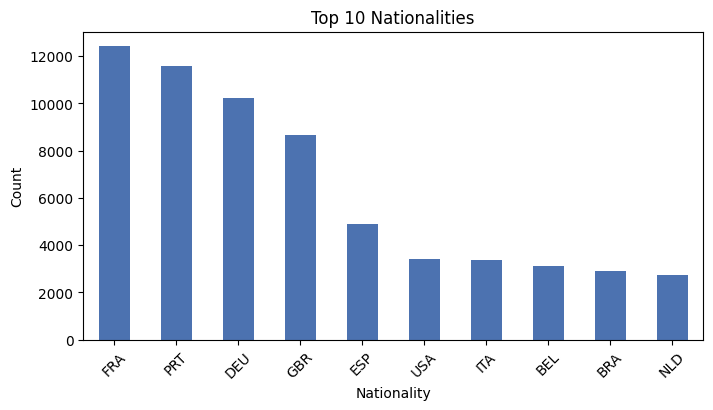

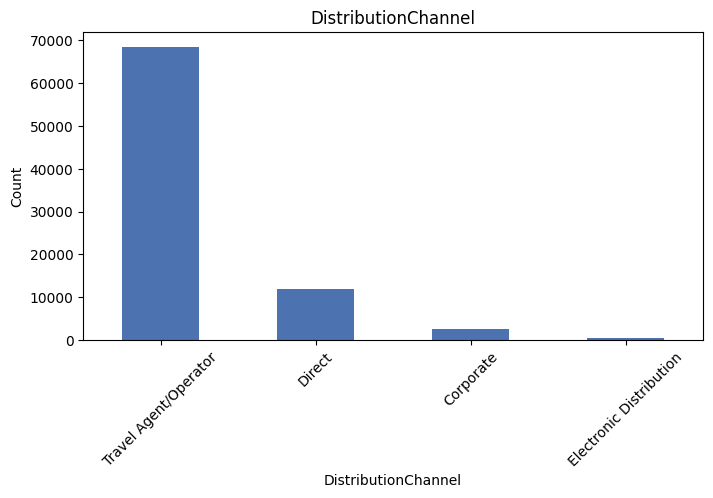

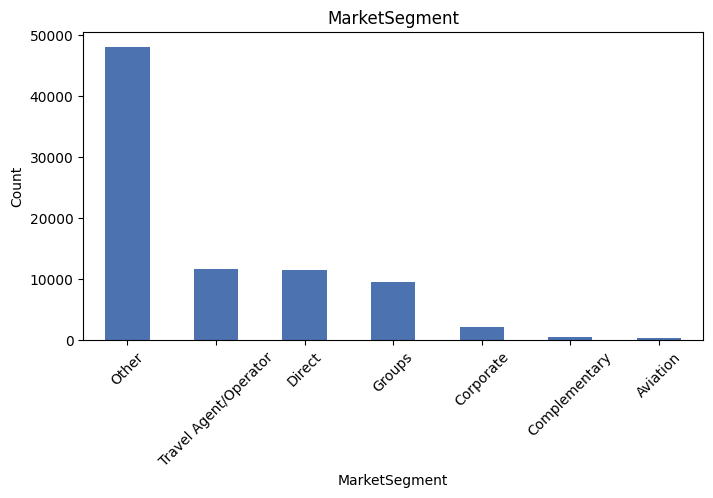

In [8]:
sns.set_palette("deep")

for col in categorical_cols:
    
    plt.figure(figsize=(8, 4))
    
    if col == "Nationality":
        df[col].value_counts().head(10).plot(kind="bar")
        plt.title("Top 10 Nationalities")
    else:
        df[col].value_counts().plot(kind="bar")
        plt.title(col)
    
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()


#### Key Findings:

- `Nationality` has high cardinality, with 188 different categories.

- The most frequent nationalities are:
    - FRA: 14.86%
    - PRT: 13.87%
    - DEU: 12.24%
    - GBR: 10.36%
    - ESP: 5.86%

- Several nationalities have only 1 observation, so rare categories will be grouped as `Other` in data preparation.

- `DistributionChannel` is highly concentrated in one category:
    - Travel Agent/Operator: 82.03%

- Direct bookings represent 14.25% of customers, while Corporate and Electronic Distribution are much smaller categories.

- `MarketSegment` is also concentrated:
    - Other: 57.47%

- The main market segments after `Other` are:
    - Travel Agent/Operator: 13.96%
    - Direct: 13.71%
    - Groups: 11.37%

- Corporate, Complementary, and Aviation represent very small segments.


## B. Numerical Variables

For the numerical univariate analysis, the binary variables were excluded as they will be assessed next.

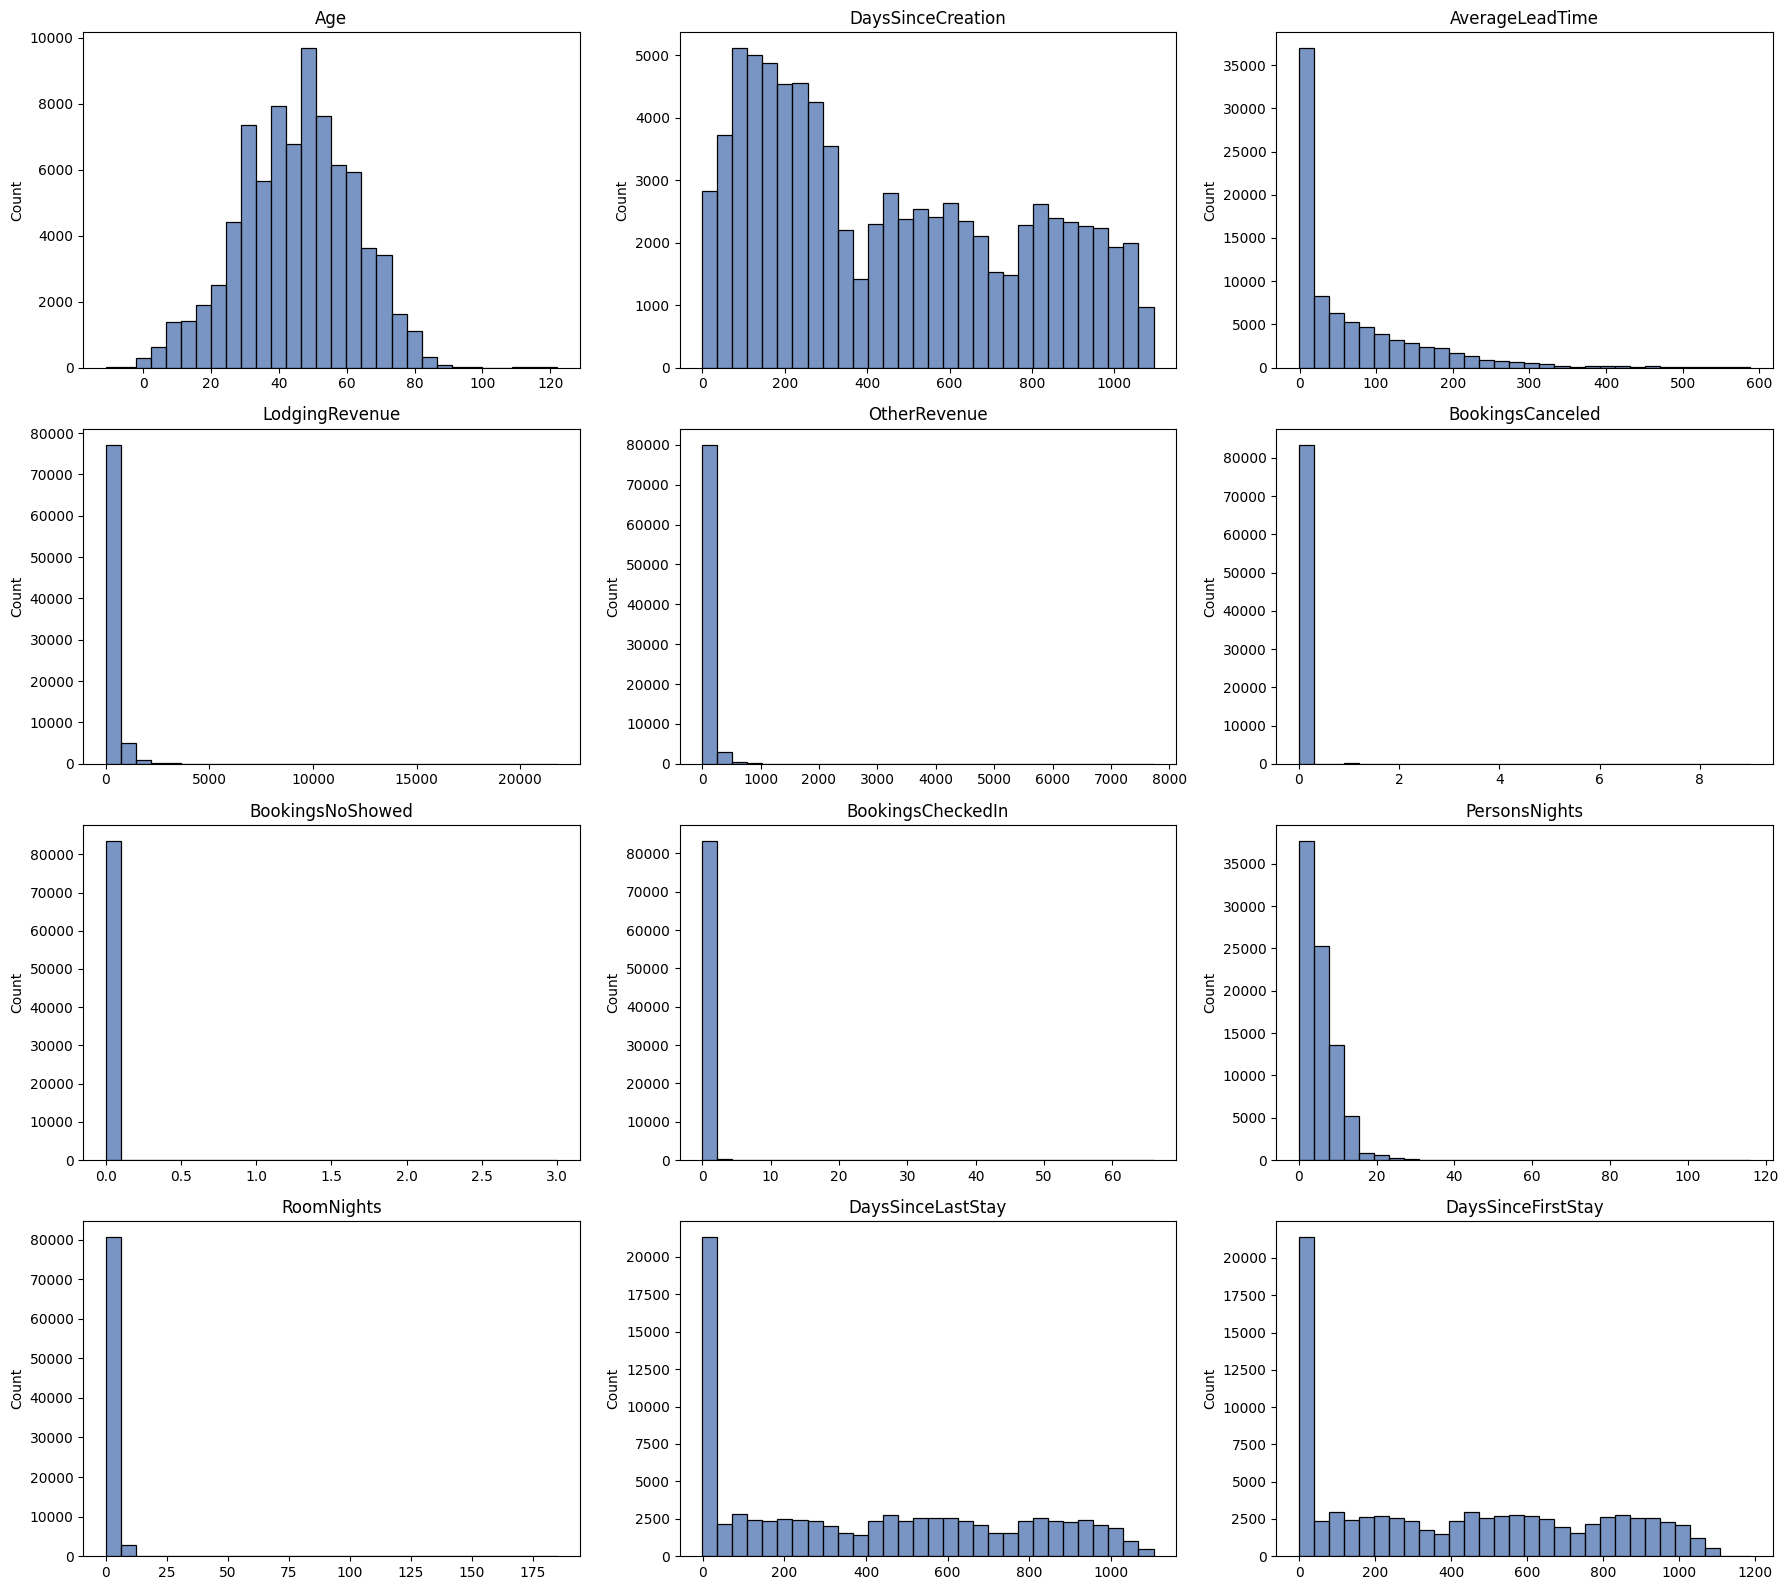

In [9]:
# distribution visualization
numerical_cols = df.select_dtypes(include=[np.number]).columns
numerical_cols = numerical_cols.drop(["ID",
    "SRHighFloor",
    "SRLowFloor",
    "SRAccessibleRoom",
    "SRMediumFloor",
    "SRBathtub",
    "SRShower",
    "SRCrib",
    "SRKingSizeBed",
    "SRTwinBed",
    "SRNearElevator",
    "SRAwayFromElevator",
    "SRNoAlcoholInMiniBar",
    "SRQuietRoom"
])

fig, axes = plt.subplots(4, 3, figsize=(18, 16))

for col, ax in zip(numerical_cols, axes.flatten()):
    sns.histplot(data=df, x=col, bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


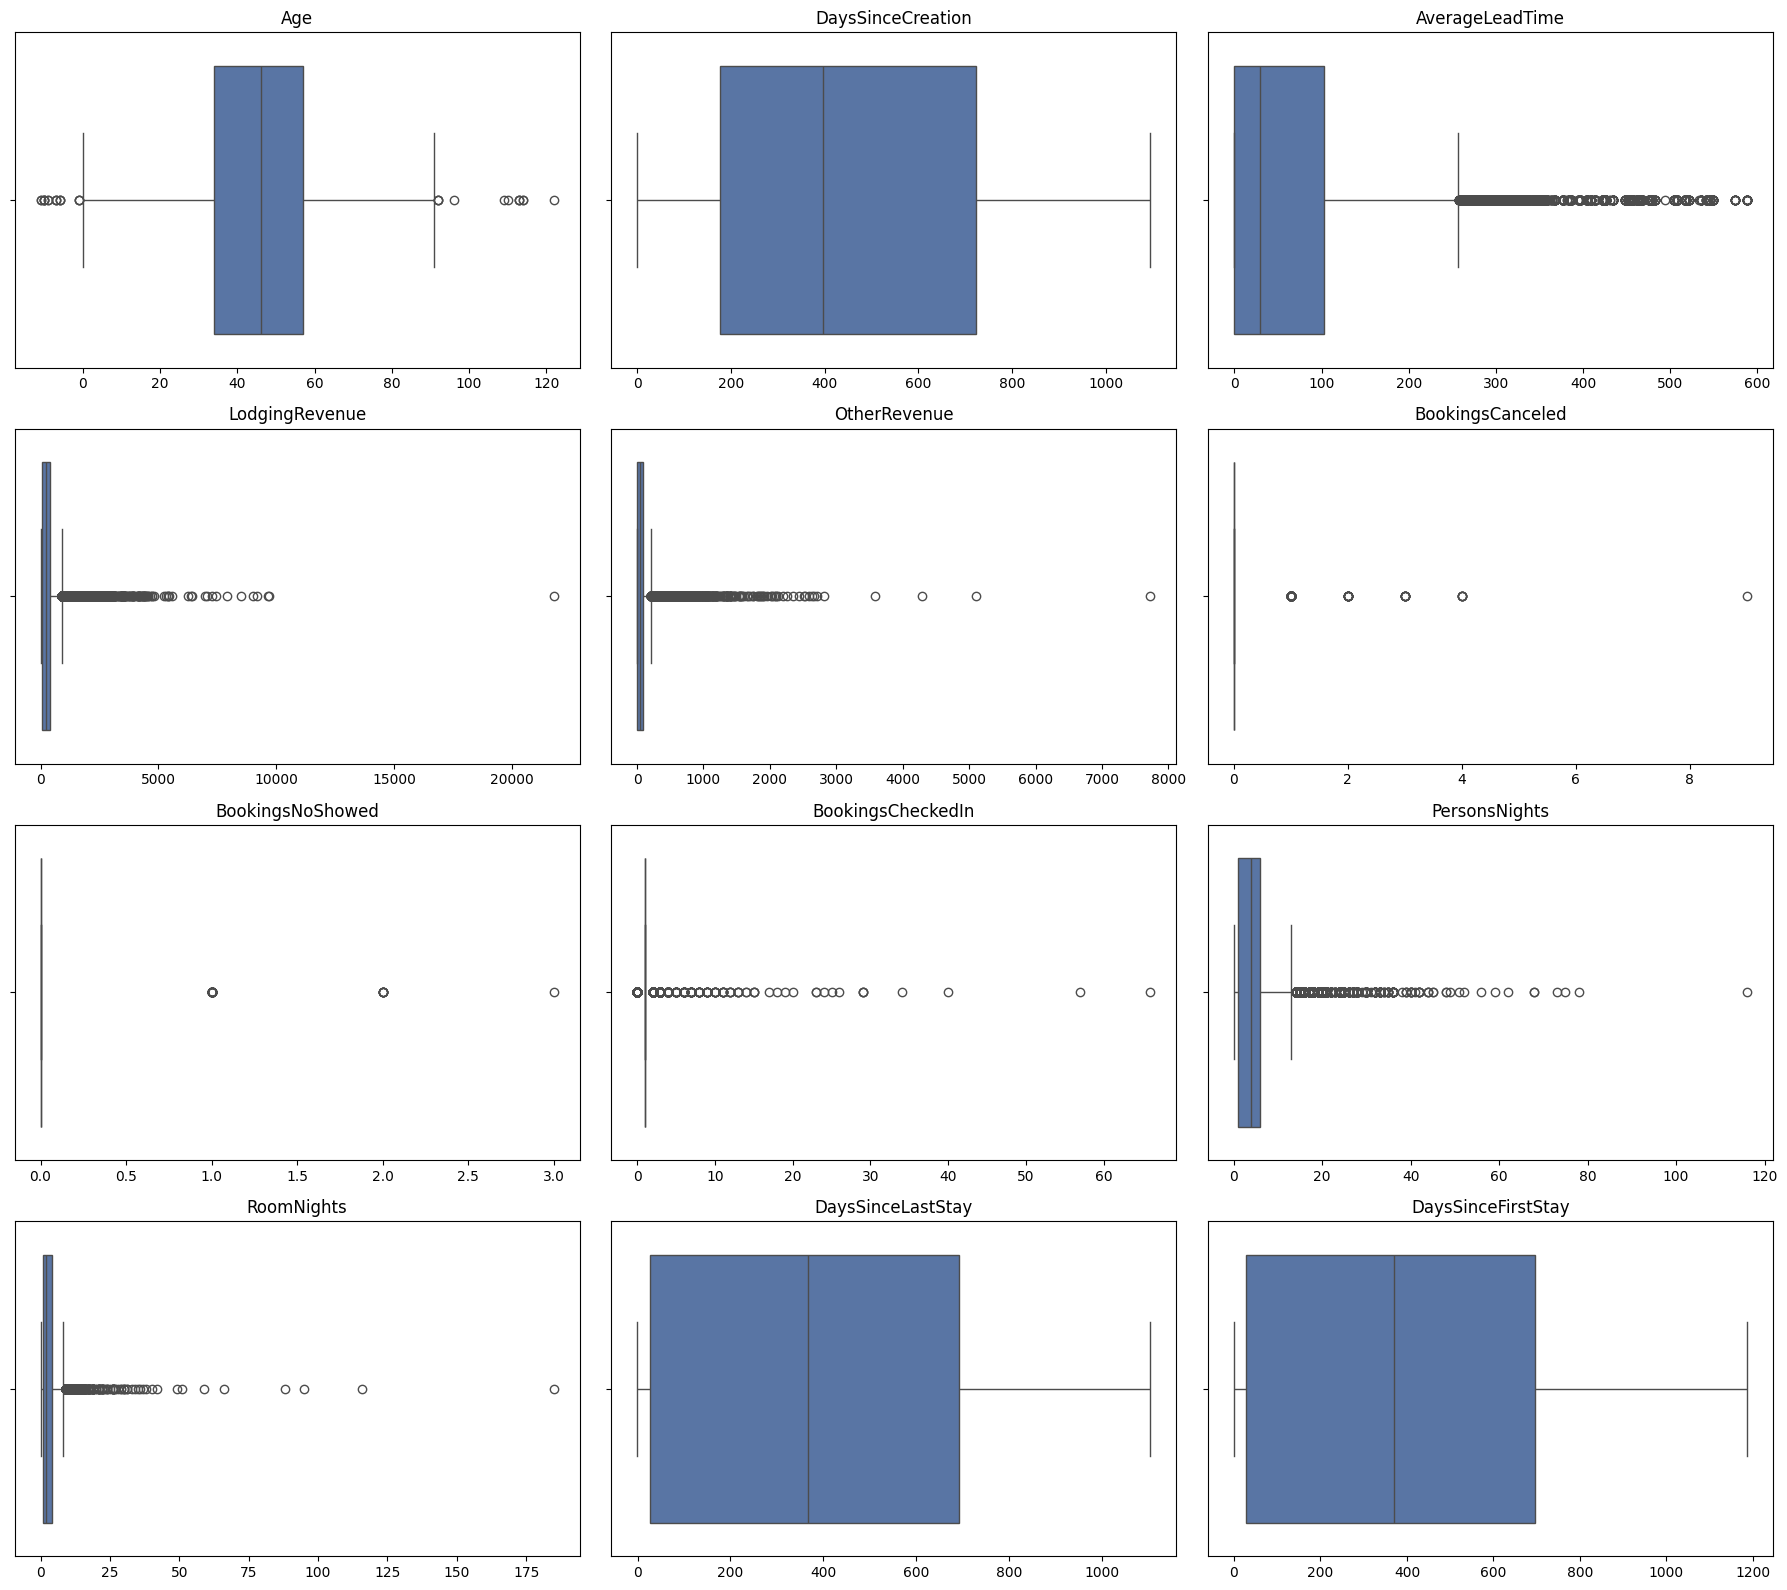

In [10]:
# outlier visualization
fig, axes = plt.subplots(4, 3, figsize=(18, 16))

for col, ax in zip(numerical_cols, axes.flatten()):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [11]:
# variables with many zeros
zeros_summary = pd.DataFrame({
    "Zero Count": (df[numerical_cols] == 0).sum(),
    "Zero Percentage": ((df[numerical_cols] == 0).sum() / len(df) * 100).round(2)
})

zeros_summary = zeros_summary.sort_values('Zero Percentage', ascending=False)
display(zeros_summary)

,Zero Count,Zero Percentage
BookingsNoShowed,83546,99.95
BookingsCanceled,83472,99.86
AverageLeadTime,22713,27.17
LodgingRevenue,20408,24.41
OtherRevenue,20214,24.18
BookingsCheckedIn,19920,23.83
PersonsNights,19922,23.83
RoomNights,19920,23.83
DaysSinceCreation,97,0.12
Age,42,0.05


#### Key Findings:

- Around 24% of customers have zero lodging revenue, zero room nights, zero person nights, and zero checked-in bookings. This indicates a relevant group of customers with **no completed stay activity**.

- LodgingRevenue and OtherRevenue are highly right-skewed. Most customers generate low or moderate revenue, while a small number of customers generate very high spending. This may suggest the presence of high-value customers who may be important for loyalty strategies, premium offers, or personalized campaigns.

- AverageLeadTime is also right-skewed, with many customers booking with little or no advance time, while others book far in advance.

- BookingsCanceled and BookingsNoShowed are almost always zero, so cancellation is **rare** in the dataset.

- BookingsCheckedIn, PersonsNights, and RoomNights are highly concentrated at low values but contain some very high values.

- DaysSinceLastStay and DaysSinceFirstStay are spread across the full time period.

- The most relevant numerical variables for segmentation are likely to be revenue, booking activity, stay intensity, recency, customer tenure, and lead time.


## C. Binary Variables

In [12]:
binary_cols = [col for col in df.columns if set(df[col].unique()).issubset({0, 1})]

# checking counts of zeros and ones and their proportion within the variable
for col in binary_cols:
    counts = df[col].value_counts(ascending=False)
    percentages = df[col].value_counts(normalize=True) * 100
    
    summary = pd.DataFrame({
        "Counts": counts,
        "Percentages": percentages
    })
    print(f'\n-------{col}-------\n')
    print(summary)


-------SRHighFloor-------

             Counts  Percentages
SRHighFloor                     
0             79621    95.251824
1              3969     4.748176

-------SRLowFloor-------

            Counts  Percentages
SRLowFloor                     
0            83472    99.858835
1              118     0.141165

-------SRAccessibleRoom-------

                  Counts  Percentages
SRAccessibleRoom                     
0                  83569    99.974877
1                     21     0.025123

-------SRMediumFloor-------

               Counts  Percentages
SRMediumFloor                     
0               83517    99.912669
1                  73     0.087331

-------SRBathtub-------

           Counts  Percentages
SRBathtub                     
0           83352    99.715277
1             238     0.284723

-------SRShower-------

          Counts  Percentages
SRShower                     
0          83447    99.828927
1            143     0.171073

-------SRCrib-------

        Coun

#### Key Findings:

- Most special request variables are highly imbalanced, with the majority of customers not making these requests.

- As seen in the initial statistics, the most common special request is `SRKingSizeBed`: 35.27% of customers requested it.

- The second most common special request is `SRTwinBed`: 14.25% of customers requested twin beds.

- `SRQuietRoom` is also relevant: 8.84% of customers requested a quiet room.

- All other special requests are very rare.

## 2.3.2 Multivariate Analysis

Objectives of the bivariate analysis:

- Compare customer value and activity across market segments, channels, and main nationalities.
- Identify whether some acquisition sources or national markets are associated with higher customer value.

### A. Correlation between customer value and stay activity

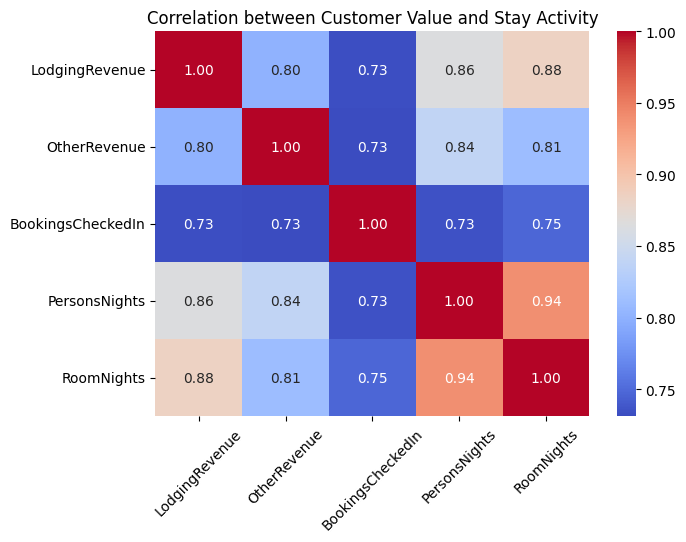

In [13]:
value_activity_cols = ["LodgingRevenue", "OtherRevenue", "BookingsCheckedIn", "PersonsNights", "RoomNights"]

value_activity_corr = df[value_activity_cols].corr(method="spearman")

plt.figure(figsize=(7, 5))

sns.heatmap(value_activity_corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation between Customer Value and Stay Activity")
plt.xticks(rotation=45)
plt.show()

### B. Recency and customer history vs value

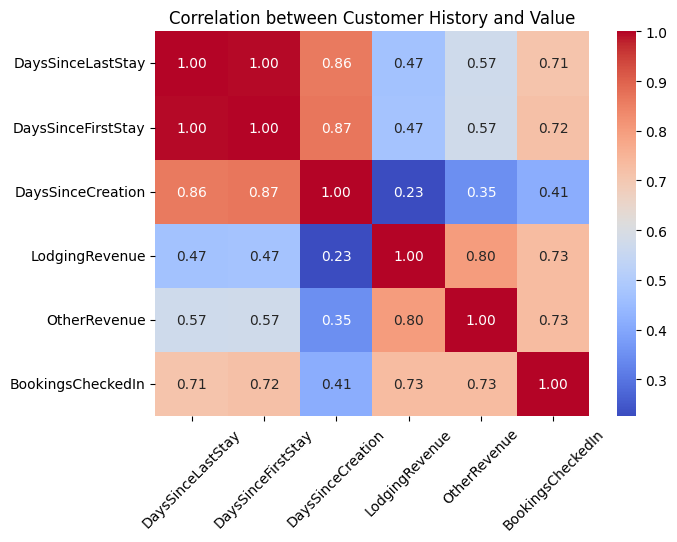

In [14]:
history_value_cols = ["DaysSinceLastStay", "DaysSinceFirstStay", "DaysSinceCreation", "LodgingRevenue", "OtherRevenue", "BookingsCheckedIn"]

history_value_corr = df[history_value_cols].corr(method='spearman')

plt.figure(figsize=(7, 5))

sns.heatmap(history_value_corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation between Customer History and Value")
plt.xticks(rotation=45)
plt.show()

### C. Customer value by market and booking channel

This analysis compares the different customer segments to see which ones spend more, book more often, and stay more nights.

In [15]:
value_cols = ["LodgingRevenue", "OtherRevenue", "BookingsCheckedIn", "RoomNights"]

market_segment_summary = (df.groupby("MarketSegment")[value_cols]
                          .mean()
                          .round(2)
                          .sort_values("LodgingRevenue", ascending=False))

distribution_summary = (df.groupby("DistributionChannel")[value_cols]
                        .mean()
                        .round(2)
                        .sort_values("LodgingRevenue", ascending=False))


top_10_nationalities = df["Nationality"].value_counts().head(10).index

nationality_summary = (df[df["Nationality"].isin(top_10_nationalities)]
                       .groupby ("Nationality")[value_cols]
                       .mean()
                       .round(2)
                       .sort_values("LodgingRevenue", ascending=False))

display(nationality_summary)
display(distribution_summary)
display(market_segment_summary)

,LodgingRevenue,OtherRevenue,BookingsCheckedIn,RoomNights
Nationality,,,,
BEL,335.90,84.10,0.76,2.49
NLD,331.91,68.71,0.77,2.43
GBR,311.13,68.30,0.77,2.41
ITA,306.90,71.45,0.78,2.39
FRA,306.66,83.17,0.77,2.50
DEU,304.28,70.91,0.78,2.57
ESP,301.08,65.25,0.83,2.22
BRA,271.51,64.05,0.71,2.25
USA,263.44,53.73,0.73,1.89


,LodgingRevenue,OtherRevenue,BookingsCheckedIn,RoomNights
DistributionChannel,,,,
Corporate,326.38,66.93,1.40,3.00
Direct,302.84,66.09,0.77,2.06
Travel Agent/Operator,297.15,68.13,0.78,2.39
Electronic Distribution,285.46,33.61,1.01,2.11


,LodgingRevenue,OtherRevenue,BookingsCheckedIn,RoomNights
MarketSegment,,,,
Aviation,533.99,80.84,1.47,4.99
Other,316.83,66.74,0.75,2.33
Direct,316.76,68.92,0.76,2.09
Corporate,310.86,65.12,1.44,2.80
Groups,277.41,64.23,0.84,2.35
Travel Agent/Operator,229.30,74.89,0.81,2.64
Complementary,22.81,16.79,1.14,1.96


#### Key Findings:

- Among the top 10 nationalities, `BEL`, `NLD`, `GBR`, `ITA`, `FRA`, and `DEU` show the highest average lodging revenue.

- `PRT` customers have the lowest average lodging revenue among the top 10 nationalities, but the highest average number of checked-in bookings.

- `FRA` and `BEL` have relatively high `OtherRevenue`, suggesting stronger spending beyond lodging.

- By distribution channel, `Corporate` customers show the highest average lodging revenue, checked-in bookings, and room nights.

- By market segment, `Aviation` has the highest average lodging revenue, bookings, and room nights, but this segment is small.

- `Travel Agent/Operator` market segment has lower lodging revenue but relatively high room nights, suggesting longer or lower-rate stays.

## 2.4 Verify Data Quality

After exploring the dataset, additional checks were performed to verify consistency, plausibility, and potential quality issues identified during the previous analysis.

## A. Implausible Values

In [16]:
# counting suspicious age values and underage companions
print('Age < 0:', (df['Age'] < 0).sum())
print('Age > 100:', (df['Age'] > 100).sum())
print('Age 0–17 (potential child companions):', ((df['Age'] >= 0) & (df['Age'] < 18)).sum())

Age < 0: 17
Age > 100: 8
Age 0–17 (potential child companions): 4397


#### Key Findings:

- There are **17 customers with negative age values**, which will be treated in data preparation.
- There are **8 customers older than 100**, which are suspicious and will also be treated in the next phase.
- There are **4,397 customers aged 0–17**. These very likely represent children or younger guests accompanying adults.

In [17]:
# checking negative average lead time
print('AverageLeadTime = -1:', (df['AverageLeadTime'] == -1).sum())
print('AverageLeadTime = 0:', (df['AverageLeadTime'] == 0).sum())

AverageLeadTime = -1: 10
AverageLeadTime = 0: 22713


#### KEy Findings:

- `AverageLeadTime` has **10 records with a value of -1**. Since lead time represents the number of days between booking and arrival, negative values are not valid and will be later treated.
- `AverageLeadTime = 0` appears in **22,713 records**. This is plausible and probably represents bookings made on the same day.
- Therefore, only `AverageLeadTime = -1` is considered problematic.

In [18]:
# consistency checks between booking, stay, and revenue variables
consistency_checks = pd.DataFrame({
    "Check": [
        "No checked-in bookings but positive room/person nights",
        "Positive room nights but no checked-in bookings",
        "Positive person nights but no checked-in bookings",
        "Zero room nights but positive lodging revenue"],
    
    "Inconsistent Records": [
        ((df["BookingsCheckedIn"] == 0) & ((df["RoomNights"] > 0) | (df["PersonsNights"] > 0))).sum(),
        ((df["RoomNights"] > 0) & (df["BookingsCheckedIn"] == 0)).sum(),
        ((df["PersonsNights"] > 0) & (df["BookingsCheckedIn"] == 0)).sum(),
        ((df["RoomNights"] == 0) & (df["LodgingRevenue"] > 0)).sum()]
})

display(consistency_checks)

,Check,Inconsistent Records
0,No checked-in bookings but positive room/perso...,0
1,Positive room nights but no checked-in bookings,0
2,Positive person nights but no checked-in bookings,0
3,Zero room nights but positive lodging revenue,0


In [19]:
# consistency check of -1 value in stay date variables
special_stay_code_checks = pd.DataFrame({
    "Check": [
        "DaysSinceLastStay = -1 but customer has checked-in bookings",
        "DaysSinceFirstStay = -1 but customer has checked-in bookings",
        "BookingsCheckedIn = 0 but DaysSinceLastStay is not -1",
        "BookingsCheckedIn = 0 but DaysSinceFirstStay is not -1"],
    
    "Inconsistent Records": [
        ((df["DaysSinceLastStay"] == -1) & (df["BookingsCheckedIn"] > 0)).sum(),
        ((df["DaysSinceFirstStay"] == -1) & (df["BookingsCheckedIn"] > 0)).sum(),
        ((df["BookingsCheckedIn"] == 0) & (df["DaysSinceLastStay"] != -1)).sum(),
        ((df["BookingsCheckedIn"] == 0) & (df["DaysSinceFirstStay"] != -1)).sum()]
})

display(special_stay_code_checks)

,Check,Inconsistent Records
0,DaysSinceLastStay = -1 but customer has checke...,0
1,DaysSinceFirstStay = -1 but customer has check...,0
2,BookingsCheckedIn = 0 but DaysSinceLastStay is...,0
3,BookingsCheckedIn = 0 but DaysSinceFirstStay i...,0


#### Key Findings:

**Booking, Stay, and Revenue Consistency:**
- No inconsistencies were found. Customers with no checked-in bookings do not have positive room nights or person nights and customers with zero room nights do not have positive lodging revenue.

**Stay Date Special Code Consistency:**
- No inconsistencies were found either. Customers with `DaysSinceLastStay = -1` or `DaysSinceFirstStay = -1` do not have checked-in bookings.

## B. Zero Lodging Revenue Investigation

A total of **20,408 customers (24.4%)** have zero `LodgingRevenue`. This was investigated further.

In [20]:
zero_lodging = df[df['LodgingRevenue'] == 0]

# group 1: zero lodging and no stay activity whatsoever (plausible)
zero_lodging_no_stay = df[(df["LodgingRevenue"] == 0) & (df["BookingsCheckedIn"] == 0) & (df["RoomNights"] == 0) & (df["PersonsNights"] == 0)]

# group 2: zero lodging but has actual stay activity 
zero_lodging_with_stay = df[(df['LodgingRevenue'] == 0) & ((df['BookingsCheckedIn'] > 0) | (df['RoomNights'] > 0) | (df['PersonsNights'] > 0))]

print(f"Total zero LodgingRevenue: {len(zero_lodging)} ({len(zero_lodging)/len(df)*100:.1f}%)")
print(f"Zero lodging and no stay activity: {len(zero_lodging_no_stay)} ({len(zero_lodging_no_stay)/len(df)*100:.1f}%)")
print(f"Zero lodging but with stay activity: {len(zero_lodging_with_stay)} ({len(zero_lodging_with_stay)/len(df)*100:.1f}%)")

Total zero LodgingRevenue: 20408 (24.4%)
Zero lodging and no stay activity: 19920 (23.8%)
Zero lodging but with stay activity: 488 (0.6%)


#### Key Findings:

- Confirming what was seen above, `20,408` customers have `LodgingRevenue = 0`, representing `24.4%` of the dataset.
- Most of these customers have no actual stay activity. However, `488` customers have zero lodging revenue despite having stay activity. Since they represent only around `0.6%` of the dataset, they are not a major issue.

In [21]:
# profiling the suspicious customers with zero lodging revenue and no stay activity
print("----Zero lodging with no stay activity----")
print(f"DaysSinceLastStay = -1: {(zero_lodging_no_stay['DaysSinceLastStay'] == -1).sum():,}")
print(f"DaysSinceFirstStay = -1: {(zero_lodging_no_stay['DaysSinceFirstStay'] == -1).sum():,}")
print(f"OtherRevenue > 0: {(zero_lodging_no_stay['OtherRevenue'] > 0).sum():,}")


# profilinh the zero lodging but stayed customers
print("----Zero lodging with stay activity----")
print("Market segment breakdown:")
display(pd.DataFrame({
    "Count": zero_lodging_with_stay["MarketSegment"].value_counts(),
    "Percentage": zero_lodging_with_stay["MarketSegment"].value_counts(normalize=True).mul(100).round(1)
}))

print("Distribution channel breakdown:")
display(pd.DataFrame({
    "Count": zero_lodging_with_stay["DistributionChannel"].value_counts(),
    "Percentage": zero_lodging_with_stay["DistributionChannel"].value_counts(normalize=True).mul(100).round(1)
}))

print("Stay activity summary:")
display(zero_lodging_with_stay[["BookingsCheckedIn", "RoomNights", "PersonsNights", "OtherRevenue"]].describe().round(2))

----Zero lodging with no stay activity----
DaysSinceLastStay = -1: 19,920
DaysSinceFirstStay = -1: 19,920
OtherRevenue > 0: 0
----Zero lodging with stay activity----
Market segment breakdown:


,Count,Percentage
MarketSegment,,
Complementary,356,73.0
Groups,62,12.7
Direct,30,6.1
Travel Agent/Operator,28,5.7
Corporate,7,1.4
Other,5,1.0


Distribution channel breakdown:


,Count,Percentage
DistributionChannel,,
Direct,311,63.7
Travel Agent/Operator,158,32.4
Corporate,19,3.9


Stay activity summary:


,BookingsCheckedIn,RoomNights,PersonsNights,OtherRevenue
count,488.00,488.00,488.00,488.00
mean,1.24,2.29,3.56,37.36
std,1.68,2.55,4.65,279.38
min,1.00,1.00,1.00,0.00
25%,1.00,1.00,2.00,0.00
50%,1.00,2.00,3.00,0.00
75%,1.00,3.00,4.00,9.00
max,34.00,38.00,78.00,5105.50


#### Key Findings:

- Most of the "no lodging but stay activity" cases belong to the `Complementary` market segment:
    - `356` customers, representing `73.0%` of this group, i.e. most zero-revenue stays are likely free or complimentary stays.
- The remaining cases are spread across Groups, Direct, Travel Agent/Operator, Corporate, and Other, so they may represent special cases or data errors.
- These customers usually have low stay activity:
    - Median `BookingsCheckedIn`: 1
    - Median `RoomNights`: 2
    - Median `PersonsNights`: 3
- However, a few extreme cases exist, with up to `34` checked-in bookings, `38` room nights, and `78` person nights.
- Since this group represents only `0.6%` of the dataset, it is not a major data quality issue, but it will be treated in data preparation.

## C. Duplicate Profiles

Since `ID` is unique by design, duplicate profiles were checked after excluding the `ID` column. This verifies whether the same customer profile appears more than once with different IDs.

In [22]:
# checking for exact duplicates not counting ID
cols_without_id = [col for col in df.columns if col != 'ID']

# marking all rows that are duplicated across every column except ID. keep=False marks all copies of a duplicated profile, not only the repeated ones.
exact_dup_mask = df.duplicated(subset=cols_without_id, keep=False)

print(f'Rows involved in exact duplicates: {exact_dup_mask.sum()}')
print(f'Rows to remove (keeping first occurrence): {df.duplicated(subset=cols_without_id).sum()}')
print(f'Unique duplicated NameHash values: {df[exact_dup_mask]["NameHash"].nunique()}')
print(f'Unique duplicated DocIDHash values: {df[exact_dup_mask]["DocIDHash"].nunique()}\n')


print('Number of times each duplicated profile appears, using NameHash + DocIDHash:')
display(
    df[exact_dup_mask]
    .groupby(['NameHash', 'DocIDHash'])
    .size()
    .value_counts()
    .rename_axis('copies')
    .rename('profiles')
)

Rows involved in exact duplicates: 144
Rows to remove (keeping first occurrence): 80
Unique duplicated NameHash values: 50
Unique duplicated DocIDHash values: 27

Number of times each duplicated profile appears, using NameHash + DocIDHash:


copies
2     42
3      5
7      1
8      1
30     1
Name: profiles, dtype: int64

#### Key Findings:

- 144 rows are involved in exact duplicates, meaning **80 rows are redundant copies** of an existing record.

- These belong to **50 unique customers** (identified by NameHash + DocIDHash), some appearing up to 30 times.

- Since every field except `ID` is identical, these are unambiguously the same record entered multiple times in the PMS. They will be removed, keeping the first occurrence.

- However, this only addresses exact copies. The fact that 50 customers share a NameHash and 27 share a DocIDHash across these duplicates raises a further question: do other customers also appear more than once, with slightly different records?

In [23]:
# checking if the same identifier appears across non-identical rows, which would indicate a customer whose history is split across multiple distinct profiles

identifier_summary = pd.DataFrame({
    'Rows sharing identifier': [
        df.duplicated(subset=['NameHash'], keep=False).sum(),
        df.duplicated(subset=['DocIDHash'], keep=False).sum()
    ],
    'Unique repeated identifiers': [
        df[df.duplicated(subset=['NameHash'], keep=False)]['NameHash'].nunique(),
        df[df.duplicated(subset=['DocIDHash'], keep=False)]['DocIDHash'].nunique()
    ]
}, index=['NameHash', 'DocIDHash'])

display(identifier_summary)

,Rows sharing identifier,Unique repeated identifiers
NameHash,5207,2259
DocIDHash,8851,2254


#### Key Findings:

- Far beyond the 80 exact duplicates, **5,207 rows share a repeated NameHash** (2,259 unique names) and **8,851 rows share a repeated DocIDHash** (2,254 unique documents) across records that are *not* identical. 

- Matching on either identifier alone is not sufficient to confirm the same person: the same name can belong to two different people, and a repeated document hash may arise from system defaults. The next check combines both to get a stronger interpretation.

In [24]:
# customers sharing both NameHash and DocIDHash across different observations (strongest candidates for being the same real person)

both_match = df.duplicated(subset=['NameHash', 'DocIDHash'], keep=False)

print(f'Rows sharing both NameHash and DocIDHash: {both_match.sum()}')
print(f'Unique (NameHash, DocIDHash) pairs affected: {df[both_match].groupby(["NameHash", "DocIDHash"]).ngroups}\n')

# of these, how many are already covered by the exact duplicates?
exact_dup_mask = df.duplicated(subset=cols_without_id, keep=False)
additional = both_match & ~exact_dup_mask
print(f'Of these, already covered by exact duplicates: {(both_match & exact_dup_mask).sum()}')
print(f'Same NameHash + DocIDHash but different behaviour fields: {additional.sum()}')

Rows sharing both NameHash and DocIDHash: 4237
Unique (NameHash, DocIDHash) pairs affected: 1845

Of these, already covered by exact duplicates: 144
Same NameHash + DocIDHash but different behaviour fields: 4093


#### Key Findings:

- **4,093 rows** share both `NameHash` and `DocIDHash` but have different behavioural fields, belonging to **1,845 unique customer pairs**. Same name, same document, different 
activity, i.e. the same real customer's history split across multiple profiles.

- The combination of both identifiers makes it reasonable to treat these as the same real person.

**These will be merged in data preparation.**

## D. Outlier Detection

IQR lower bounds are negative for all variables in this dataset because distributions are zero-heavy and right-skewed. No actual values fall below them. Only the upper bound is meaningful so we are looking for unusually high values only.

In [25]:
outlier_cols = ['Age', 'AverageLeadTime', 'LodgingRevenue', 'OtherRevenue', 'PersonsNights', 'RoomNights']
outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    above_ub = (df[col] > upper_bound).sum()
    
    outlier_summary.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR Upper Bound': round(upper_bound, 2),
        'Actual Max': df[col].max(),
        'Above Upper Bound': above_ub,
        'Above UB %': round(above_ub / len(df) * 100, 2)
    })

display(pd.DataFrame(outlier_summary).sort_values('Above UB %', ascending=False))

,Variable,Q1,Q3,IQR Upper Bound,Actual Max,Above Upper Bound,Above UB %
3,OtherRevenue,2.0,87.68,216.19,7730.25,5057,6.05
4,PersonsNights,1.0,6.00,13.50,116.00,3925,4.70
2,LodgingRevenue,59.0,402.00,916.50,21781.00,3900,4.67
1,AverageLeadTime,0.0,103.00,257.50,588.00,3408,4.08
5,RoomNights,1.0,4.00,8.50,185.00,655,0.78
0,Age,34.0,57.00,91.50,122.00,12,0.01


#### Key Findings:

- The gap between the IQR upper bound and the actual maximum is extreme for every variable: `LodgingRevenue` (€917 -> €21,781), `OtherRevenue` (€216 -> €7,730), `PersonsNights`  (13 -> 116). IQR upper bounds are not ideal to use as removal thresholds here.

- `OtherRevenue`, `PersonsNights`, `LodgingRevenue`, and `AverageLeadTime` flag between 4–6% of rows as above the upper bound, confirming that the right tail is substantial and contains real customers, not errors.

- `Age` is the only variable where IQR is interpretable: the upper bound is 91.5, and the 12 values above it are the implausible ages over 100 already flagged in section A.

- IQR alone is insufficient to determine treatment. The percentile inspection below identifies appropriate capping thresholds for data preparation.

In [26]:
# percentile inspection to identify where genuine extremes begin and where the bulk of the data ends

for col in ['LodgingRevenue', 'OtherRevenue', 'AverageLeadTime', 'BookingsCheckedIn', 'RoomNights', 'PersonsNights']:
    p99  = df[col].quantile(0.99)
    p999 = df[col].quantile(0.999)
    print(f'{col}:')
    print(f'  p99  = {p99:.1f}  →  {(df[col] > p99).sum()} customers above')
    print(f'  p99.9 = {p999:.1f}  →  {(df[col] > p999).sum()} customers above')
    print()

LodgingRevenue:
  p99  = 1746.0  →  807 customers above
  p99.9 = 3475.3  →  84 customers above

OtherRevenue:
  p99  = 474.0  →  834 customers above
  p99.9 = 1184.1  →  84 customers above

AverageLeadTime:
  p99  = 396.0  →  799 customers above
  p99.9 = 535.0  →  73 customers above

BookingsCheckedIn:
  p99  = 2.0  →  308 customers above
  p99.9 = 6.0  →  77 customers above

RoomNights:
  p99  = 8.0  →  655 customers above
  p99.9 = 16.0  →  77 customers above

PersonsNights:
  p99  = 20.0  →  760 customers above
  p99.9 = 32.0  →  74 customers above



#### Key Findings:

**Revenue and lead time** (`LodgingRevenue`, `OtherRevenue`, `AverageLeadTime`):

- p99 thresholds are €1,746, €474, and 396 days respectively, with ~800 customers above each. p99.9 drops to ~84–73 customers, a small extreme tail.

- The p99 threshold is the appropriate cap: it preserves 99% of the distribution while controling the extreme tail. **These will be capped at p99 in data preparation.**

**Booking activity** (`BookingsCheckedIn`, `RoomNights`, `PersonsNights`):

- p99 values are extremely low: 2 check-ins, 8 room nights, 20 person nights. This is because "ghost" customers and one-time visitors make up the majority of the dataset. Capping at p99 here would cut off meaningful loyal customer behaviour.

- p99.9 is more appropriate: 6 check-ins, 16 room nights, 32 person nights. Only 74–77 customers sit above these thresholds. **These will be capped at p99.9 in data preparation.**

**General:**
- No rows are removed. All customers are retained and only extreme values are bounded to prevent problems of distance calculations in clustering.

## Data Understanding Summary

### Dataset Overview
- 83,590 customers, 31 variables
- 5 categorical variables: `Nationality`, `NameHash`, `DocIDHash`, `DistributionChannel`, `MarketSegment`
- 13 binary special request variables, already encoded as 0/1
- Only `Age` has missing values: 3,779 records (4.5%)

### Customer Profile
- Typical customer is middle-aged: mean age 45.4, median 46
- Most customers have low booking activity: median `BookingsCheckedIn` = 1
- Cancellations and no-shows are rare: `BookingsCanceled` and `BookingsNoShowed` are almost always 0
- Most common special request is `SRKingSizeBed` (35%), followed by `SRTwinBed` (14%) and `SRQuietRoom` (9%); all other SR variables are near-zero

### Distribution Channels and Market Segments
- Heavily concentrated: `Travel Agent/Operator` accounts for 82% of distribution channel and is the dominant market segment after `Other` (57%)
- `Corporate` channel customers show the highest average lodging revenue, bookings, and room nights
- `Aviation` segment has the highest average revenue but is very small in size

### Nationality
- 188 unique nationalities: top 5 are FRA (14.9%), PRT (13.9%), DEU (12.2%), GBR (10.4%), ESP (5.9%)
- Several nationalities have only 1 observation
- Northern European nationalities (BEL, NLD, GBR, DEU) generate the highest average lodging revenue. PRT customers book most frequently but spend less

### Data Quality Issues Found

**Implausible values:**
- 17 customers with negative age, 8 with age above 100: will be removed
- 4,397 customers aged 0–17: likely child companions, not real booking holders, therefore will be removed
- 3,779 missing age values: will be imputed
- 10 records with `AverageLeadTime = -1`: invalid and will be recoded

**Ghost customers:**
- 19,920 customers (23.8%) have zero activity across all fields and `DaysSinceLastStay = -1`
- These profiles were created but the customer never interacted with the hotel
- They carry no power for segmentation so will be excluded

**Complementary stays:**
- 488 customers (0.6%) stayed but have zero lodging revenue
- 73% belong to the `Complementary` market segment: intentional free stays, not errors. Will be kept

**Duplicate profiles:**
- 80 exact duplicate rows (excluding ID) across 50 customers: will be removed
- 4,093 rows share both `NameHash` and `DocIDHash` but have different behavioural fields, across 1,845 unique customer pairs: same real customer, split profile. Will be merged
- Remaining `NameHash`/`DocIDHash` overlaps where only one identifier matches are not merged, only noted as a data quality limitation


**Outliers:**
- Revenue and activity variables are heavily right-skewed with large gaps between IQR upper bounds and actual maximum: no values removed
- `LodgingRevenue`, `OtherRevenue`, `AverageLeadTime`: will be capped at p99
- `BookingsCheckedIn`, `RoomNights`, `PersonsNights`: p99 was too low due to ghost/one-time visitor dominance, so they will be capped at p99.9